In [58]:
# imports
import re
from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

In [2]:
# train
FILE_TRAIN_TRANSACTION = Path('datasets/train_transaction.csv')
FILE_TRAIN_IDENTITY = Path('datasets/train_identity.csv')

# test
FILE_TEST_TRANSACTION = Path('datasets/test_transaction.csv')
FILE_TEST_IDENTITY = Path('datasets/test_identity.csv')

In [3]:
# leitura eager 
df_train_transaction = pl.read_csv(FILE_TRAIN_TRANSACTION)
df_train_identity = pl.read_csv(FILE_TRAIN_IDENTITY)
## cruza os datasets
df_train = df_train_transaction.join(
    df_train_identity,
    on='TransactionID',
    how='left'
)

# leitura lazy
df_test_transaction = pl.scan_csv(FILE_TEST_TRANSACTION)
df_test_identity = pl.scan_csv(FILE_TEST_IDENTITY)
## cruza os datasets
df_test = df_test_transaction.join(
    df_test_identity,
    on='TransactionID',
    how='left'
)

In [4]:
# visualization
print(df_train.head(5))

shape: (5, 434)
┌───────────────┬─────────┬───────────────┬────────────────┬───┬───────┬───────┬────────────┬──────────────────┐
│ TransactionID ┆ isFraud ┆ TransactionDT ┆ TransactionAmt ┆ … ┆ id_37 ┆ id_38 ┆ DeviceType ┆ DeviceInfo       │
│ ---           ┆ ---     ┆ ---           ┆ ---            ┆   ┆ ---   ┆ ---   ┆ ---        ┆ ---              │
│ i64           ┆ i64     ┆ i64           ┆ f64            ┆   ┆ str   ┆ str   ┆ str        ┆ str              │
╞═══════════════╪═════════╪═══════════════╪════════════════╪═══╪═══════╪═══════╪════════════╪══════════════════╡
│ 2987000       ┆ 0       ┆ 86400         ┆ 68.5           ┆ … ┆ null  ┆ null  ┆ null       ┆ null             │
│ 2987001       ┆ 0       ┆ 86401         ┆ 29.0           ┆ … ┆ null  ┆ null  ┆ null       ┆ null             │
│ 2987002       ┆ 0       ┆ 86469         ┆ 59.0           ┆ … ┆ null  ┆ null  ┆ null       ┆ null             │
│ 2987003       ┆ 0       ┆ 86499         ┆ 50.0           ┆ … ┆ null  ┆ null  ┆

In [6]:
# normalize columns
def normalize_cols(col):
    col = re.sub(r'(.)([A-Z][a-z]+)', r'\1_\2', col)
    col = re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', col)
    return col.lower()

In [15]:
df_train = df_train.rename({col: normalize_cols(col) for col in df_train.columns})
df_test = df_test.rename({col: normalize_cols(col) for col in df_test.collect_schema().names()})

In [16]:
print(df_train)

shape: (590_540, 434)
┌────────────────┬──────────┬────────────────┬─────────────────┬───┬───────┬───────┬─────────────┬──────────────────┐
│ transaction_id ┆ is_fraud ┆ transaction_dt ┆ transaction_amt ┆ … ┆ id_37 ┆ id_38 ┆ device_type ┆ device_info      │
│ ---            ┆ ---      ┆ ---            ┆ ---             ┆   ┆ ---   ┆ ---   ┆ ---         ┆ ---              │
│ i64            ┆ i64      ┆ i64            ┆ f64             ┆   ┆ str   ┆ str   ┆ str         ┆ str              │
╞════════════════╪══════════╪════════════════╪═════════════════╪═══╪═══════╪═══════╪═════════════╪══════════════════╡
│ 2987000        ┆ 0        ┆ 86400          ┆ 68.5            ┆ … ┆ null  ┆ null  ┆ null        ┆ null             │
│ 2987001        ┆ 0        ┆ 86401          ┆ 29.0            ┆ … ┆ null  ┆ null  ┆ null        ┆ null             │
│ 2987002        ┆ 0        ┆ 86469          ┆ 59.0            ┆ … ┆ null  ┆ null  ┆ null        ┆ null             │
│ 2987003        ┆ 0        ┆ 8649

In [27]:
# check nulls
print(
    df_train.select(pl.all().null_count() / pl.len())
    .transpose(include_header=True, column_names=['null_ratio'])
    .filter(pl.col('null_ratio') > 0.8)
)

shape: (74, 2)
┌────────┬────────────┐
│ column ┆ null_ratio │
│ ---    ┆ ---        │
│ str    ┆ f64        │
╞════════╪════════════╡
│ dist2  ┆ 0.936284   │
│ d6     ┆ 0.876068   │
│ d7     ┆ 0.934099   │
│ d8     ┆ 0.873123   │
│ d9     ┆ 0.873123   │
│ …      ┆ …          │
│ id_27  ┆ 0.991247   │
│ id_30  ┆ 0.868654   │
│ id_32  ┆ 0.868619   │
│ id_33  ┆ 0.875895   │
│ id_34  ┆ 0.868248   │
└────────┴────────────┘


Tem muito nulos mas não sei se a presença da caracteristica não é muito importante por conta disso irei deixar.

In [31]:
# separando tipos de colunas
num_cols = df_train.select(pl.selectors.numeric()).columns
cat_cols = df_train.select(pl.selectors.string()).columns

In [38]:
print(df_train.select(num_cols))

shape: (590_540, 403)
┌────────────────┬──────────┬────────────────┬─────────────────┬───┬───────┬───────┬───────┬───────┐
│ transaction_id ┆ is_fraud ┆ transaction_dt ┆ transaction_amt ┆ … ┆ id_24 ┆ id_25 ┆ id_26 ┆ id_32 │
│ ---            ┆ ---      ┆ ---            ┆ ---             ┆   ┆ ---   ┆ ---   ┆ ---   ┆ ---   │
│ i64            ┆ i64      ┆ i64            ┆ f64             ┆   ┆ f64   ┆ f64   ┆ f64   ┆ f64   │
╞════════════════╪══════════╪════════════════╪═════════════════╪═══╪═══════╪═══════╪═══════╪═══════╡
│ 2987000        ┆ 0        ┆ 86400          ┆ 68.5            ┆ … ┆ null  ┆ null  ┆ null  ┆ null  │
│ 2987001        ┆ 0        ┆ 86401          ┆ 29.0            ┆ … ┆ null  ┆ null  ┆ null  ┆ null  │
│ 2987002        ┆ 0        ┆ 86469          ┆ 59.0            ┆ … ┆ null  ┆ null  ┆ null  ┆ null  │
│ 2987003        ┆ 0        ┆ 86499          ┆ 50.0            ┆ … ┆ null  ┆ null  ┆ null  ┆ null  │
│ 2987004        ┆ 0        ┆ 86506          ┆ 50.0            ┆ … ┆ 

In [37]:
print(df_train.select(cat_cols))

shape: (590_540, 31)
┌────────────┬────────────┬────────┬───────────────┬───┬───────┬───────┬─────────────┬───────────────────────────────┐
│ product_cd ┆ card4      ┆ card6  ┆ p_emaildomain ┆ … ┆ id_37 ┆ id_38 ┆ device_type ┆ device_info                   │
│ ---        ┆ ---        ┆ ---    ┆ ---           ┆   ┆ ---   ┆ ---   ┆ ---         ┆ ---                           │
│ str        ┆ str        ┆ str    ┆ str           ┆   ┆ str   ┆ str   ┆ str         ┆ str                           │
╞════════════╪════════════╪════════╪═══════════════╪═══╪═══════╪═══════╪═════════════╪═══════════════════════════════╡
│ W          ┆ discover   ┆ credit ┆ null          ┆ … ┆ null  ┆ null  ┆ null        ┆ null                          │
│ W          ┆ mastercard ┆ credit ┆ gmail.com     ┆ … ┆ null  ┆ null  ┆ null        ┆ null                          │
│ W          ┆ visa       ┆ debit  ┆ outlook.com   ┆ … ┆ null  ┆ null  ┆ null        ┆ null                          │
│ W          ┆ mastercard ┆

In [49]:
# visualization
fraud_0 = df_train.filter(pl.col("is_fraud") == 0)["transaction_amt"].to_numpy()
fraud_1 = df_train.filter(pl.col("is_fraud") == 1)["transaction_amt"].to_numpy()

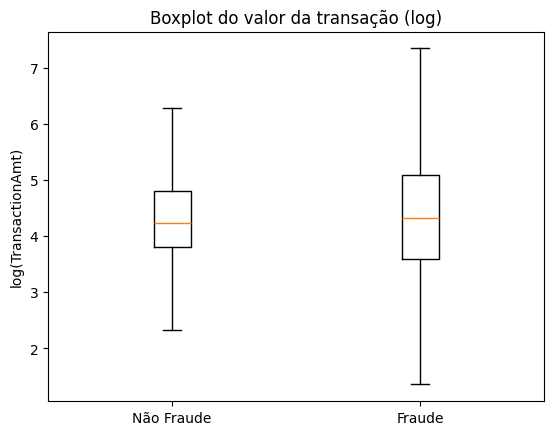

In [63]:
is_fraud_0 = np.log1p(
    df_train.filter(pl.col("is_fraud") == 0)["transaction_amt"].to_numpy()
)
is_fraud_1 = np.log1p(
    df_train.filter(pl.col("is_fraud") == 1)["transaction_amt"].to_numpy()
)

fig, ax = plt.subplots()
ax.boxplot([is_fraud_0, is_fraud_1], showfliers=False)
ax.set_ylabel("log(TransactionAmt)")
ax.set_title("Boxplot do valor da transação (log)")
ax.set_xticklabels(["Não Fraude", "Fraude"])

plt.show()

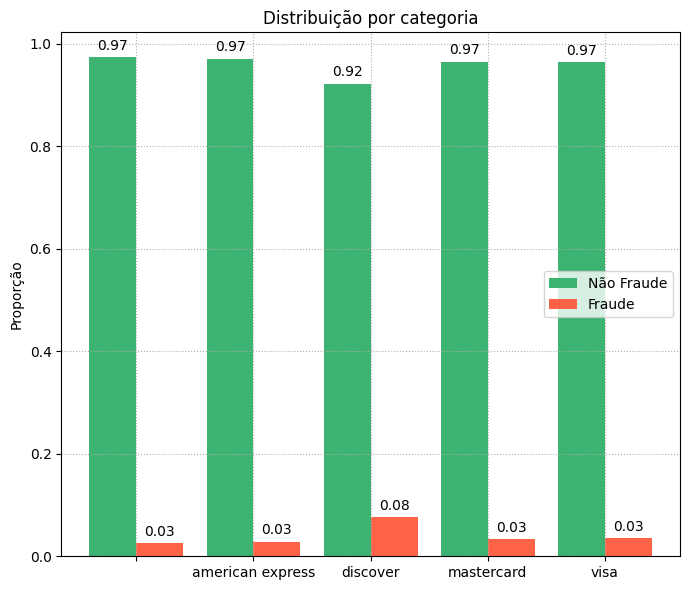

In [119]:
df_grouped = (
    df_train
    .group_by(["card4", "is_fraud"])  # target = 0/1
    .len()
    .sort("card4")
    .with_columns(
        (pl.col("len") / pl.col("len").sum().over("card4")).alias("ratio")
    )
    .pivot(
        values="ratio",
        index="card4",
        on="is_fraud"
    )
    .fill_null(0)
)


categorias = df_grouped["card4"].to_list()
val_0 = df_grouped["0"].to_list()
val_1 = df_grouped["1"].to_list()

x = np.arange(len(categorias))
width = 0.4


fig, ax = plt.subplots(figsize=(7, 6))

bars0 = ax.bar(x - width / 2, val_0, width, label="Não Fraude", color='#3CB371')
bars1 = ax.bar(x + width / 2, val_1, width, label="Fraude", color='#FF6347')

ax.set_xticks(x)
ax.set_xticklabels(categorias, rotation=0)
ax.set_ylabel("Proporção")
ax.set_title("Distribuição por categoria")

ax.legend()
ax.grid(True, linestyle=':')

ax.bar_label(bars0, fmt="%.2f", padding=3)
ax.bar_label(bars1, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()